## Transfer learning

### Instructions

In this notebook, create a neural network model to classify images of cats and dogs, using transfer learning: you will use part of a pre-trained image classifier model (trained on ImageNet) as a feature extractor, and train additional new layers to perform the cats and dogs classification task.

### Let's get started!

Start by running some imports, and loading the dataset.

In [25]:
#### PACKAGE IMPORTS ####

import tensorflow as tf
from tensorflow.keras.models import  Sequential, Model
from tensorflow.keras import layers
import numpy as np
import os
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

<img src="images/Cats-Dogs-Rex.jpg" alt="Drawing" style="height: 450px;" align="center"/>

#### The Dogs vs Cats dataset

In this assignment, you will use the [Dogs vs Cats dataset](https://www.kaggle.com/c/dogs-vs-cats/data), which was used for a 2013 Kaggle competition. It consists of 25000 images containing either a cat or a dog. We will only use a subset of 600 images and labels. The dataset is a subset of a much larger dataset of 3 million photos that were originally used as a CAPTCHA (Completely Automated Public Turing test to tell Computers and Humans Apart), referred to as “Asirra” or Animal Species Image Recognition for Restricting Access.

* J. Elson, J. Douceur, J. Howell, and J. Saul. "Asirra: A CAPTCHA that Exploits Interest-Aligned Manual Image Categorization." Proceedings of 14th ACM Conference on Computer and Communications Security (CCS), October 2007.

Your goal is to train a classifier model using part of a pre-trained image classifier, using the principle of transfer learning.

#### Load and preprocess the data

In [2]:
images_train = np.load('data/images_train.npy') / 255.
images_valid = np.load('data/images_valid.npy') / 255.
images_test = np.load('data/images_test.npy') / 255.

labels_train = np.load('data/labels_train.npy')
labels_valid = np.load('data/labels_valid.npy')
labels_test = np.load('data/labels_test.npy')

In [3]:
print("{} training data examples".format(images_train.shape[0]))
print("{} validation data examples".format(images_valid.shape[0]))
print("{} test data examples".format(images_test.shape[0]))

600 training data examples
300 validation data examples
300 test data examples


#### Display sample images and labels from the training set

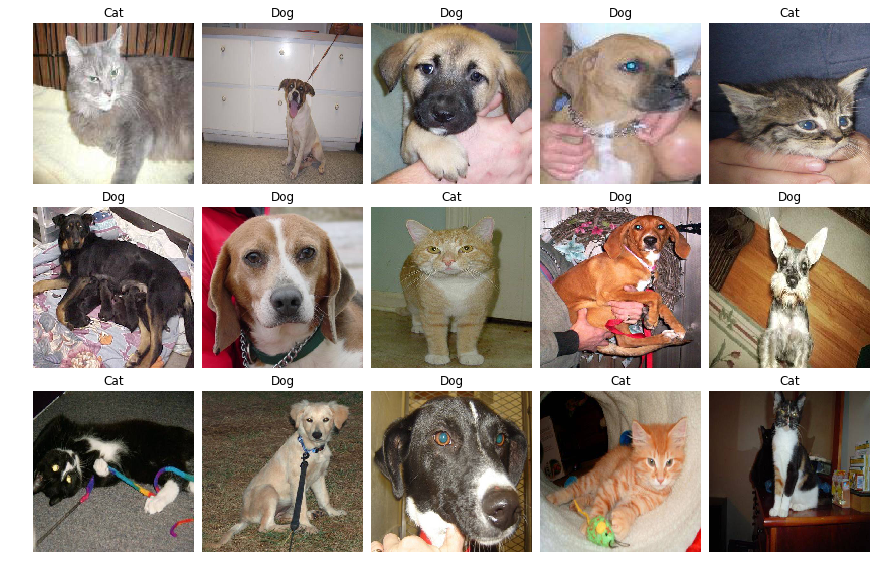

In [4]:
# Display a few images and labels

class_names = np.array(['Dog', 'Cat'])

plt.figure(figsize=(15, 10))
plt.subplots_adjust(wspace=0.05, hspace=0.05)
inx = np.random.choice(images_train.shape[0], 15, replace=False)
for n, i in enumerate(inx):
    ax = plt.subplot(3, 5, n+1)
    plt.imshow(images_train[i])
    plt.title(class_names[labels_train[i]])
    plt.axis('off')

#### Create a benchmark model

Firstly, create and train a CNN classifier model as a benchmark model before implementing the transfer learning approach. Using the functional API, build the benchmark model according to the following specifications:

* The model should use the `input_shape` in the function argument to set the shape in the Input layer.
* The first and second hidden layers should be Conv2D layers with 32 filters, 3x3 kernel size and ReLU activation.
* The third hidden layer should be a MaxPooling2D layer with a 2x2 window size.
* The fourth and fifth hidden layers should be Conv2D layers with 64 filters, 3x3 kernel size and ReLU activation.
* The sixth hidden layer should be a MaxPooling2D layer with a 2x2 window size.
* The seventh and eighth hidden layers should be Conv2D layers with 128 filters, 3x3 kernel size and ReLU activation.
* The ninth hidden layer should be a MaxPooling2D layer with a 2x2 window size.
* This should be followed by a Flatten layer, and a Dense layer with 128 units and ReLU activation
* The final layer should be a Dense layer with a single neuron and sigmoid activation.
* All of the Conv2D layers should use `'SAME'` padding.

In total, the network should have 13 layers (including the `Input` layer).

The model should then be compiled with the RMSProp optimiser with learning rate 0.001, binary cross entropy loss and binary accuracy metric.

In [5]:
def get_benchmark_model(input_shape):
    """
    This function should build and compile a CNN model according to the above specification,
    using the functional API. The function takes input_shape as an argument, which should be
    used to specify the shape in the Input layer.
    Your function should return the model.
    """
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs) 
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x) 
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(lr=1e-03),
        metrics=['acc'],
        loss='binary_crossentropy'
    )
    
    return model

In [6]:
# Build and compile the benchmark model, and display the model summary

benchmark_model = get_benchmark_model(images_train[0].shape)
benchmark_model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 160, 160, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 160, 160, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 160, 160, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 80, 80, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 80, 80, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 80, 80, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 40, 40, 64)        0     

#### Train the CNN benchmark model

We will train the benchmark CNN model using an `EarlyStopping` callback. Feel free to increase the training time if you wish.

In [7]:
# Fit the benchmark model and save its training history

earlystopping = tf.keras.callbacks.EarlyStopping(patience=2)
history_benchmark = benchmark_model.fit(
    images_train, labels_train, epochs=10, batch_size=32,
    validation_data=(images_valid, labels_valid), 
    callbacks=[earlystopping]
)

Train on 600 samples, validate on 300 samples
Epoch 1/10
600/600 [==============================] - 456s 760ms/sample - loss: 4.6734 - acc: 0.5000 - val_loss: 0.6929 - val_acc: 0.5000
Epoch 2/10
600/600 [==============================] - 455s 758ms/sample - loss: 0.6945 - acc: 0.4783 - val_loss: 0.6926 - val_acc: 0.5000
Epoch 3/10
600/600 [==============================] - 456s 760ms/sample - loss: 0.7029 - acc: 0.4900 - val_loss: 0.6938 - val_acc: 0.5033
Epoch 4/10
600/600 [==============================] - 454s 757ms/sample - loss: 0.7559 - acc: 0.5033 - val_loss: 0.6921 - val_acc: 0.5300
Epoch 5/10
600/600 [==============================] - 450s 751ms/sample - loss: 0.7242 - acc: 0.5633 - val_loss: 0.6913 - val_acc: 0.5033
Epoch 6/10
600/600 [==============================] - 456s 760ms/sample - loss: 0.7115 - acc: 0.5683 - val_loss: 0.6973 - val_acc: 0.4933
Epoch 7/10
600/600 [==============================] - 455s 759ms/sample - loss: 0.6822 - acc: 0.5650 - val_loss: 0.6903 - val_

#### Plot the learning curves

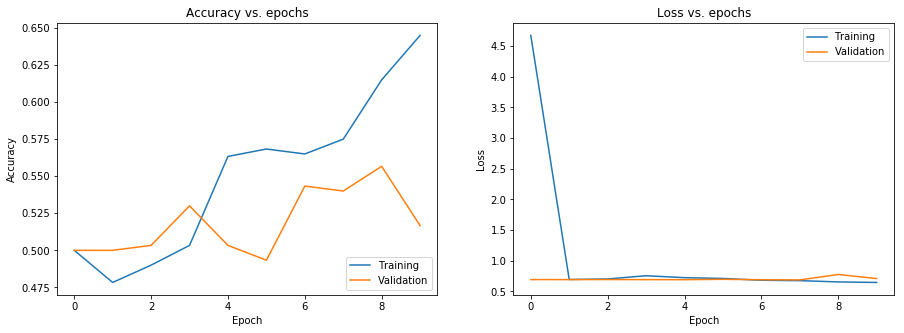

In [8]:
# plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15, 5))
plt.subplot(121)
try:
    plt.plot(history_benchmark.history['accuracy'])
    plt.plot(history_benchmark.history['val_accuracy'])
except KeyError:
    plt.plot(history_benchmark.history['acc'])
    plt.plot(history_benchmark.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history_benchmark.history['loss'])
plt.plot(history_benchmark.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

#### Evaluate the benchmark model

In [9]:
# Evaluate the benchmark model on the test set

benchmark_test_loss, benchmark_test_acc = benchmark_model.evaluate(images_test, labels_test, verbose=0)
print("Test loss: {}".format(benchmark_test_loss))
print("Test accuracy: {}".format(benchmark_test_acc))

Test loss: 0.7003795584042867
Test accuracy: 0.5199999809265137


#### Load the pretrained image classifier model

Now, build a image classifier using transfer learning.
Use the pre-trained MobileNet V2 model, available to download from [Keras Applications](https://keras.io/applications/#mobilenetv2). However, the pretrained model has already been downloaded and it is available at the location `./models/MobileNetV2.h5`.

In [10]:
def load_pretrained_MobileNetV2(path):
    """
    This function takes a path as an argument, and uses it to 
    load the full MobileNetV2 pretrained model from the path.
    Your function should return the loaded model.
    """
    loaded_model = tf.keras.models.load_model(path)
    return loaded_model
    

In [11]:
# Call the function loading the pretrained model and display its summary

base_model = load_pretrained_MobileNetV2('models/MobileNetV2.h5')
base_model.summary()

Model: "mobilenetv2_1.00_160"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
Conv1_pad (ZeroPadding2D)       (None, 161, 161, 3)  0           input_6[0][0]                    
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 80, 80, 32)   864         Conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 80, 80, 32)   128         Conv1[0][0]                      
_______________________________________________________________________________

#### Use the pre-trained model as a feature extractor

Remove the final layer of the network and replace it with new, untrained classifier layers for this task but first, create a new model that has the same input tensor as the MobileNetV2 model, and uses the output tensor from the layer with name `global_average_pooling2d_6` as the model output.

In [12]:
def remove_head(pretrained_model):
    """
    This function should create and return a new model, using the input and output 
    tensors as specified above. 
    Use the 'get_layer' method to access the correct layer of the pre-trained model.
    """
    inputs = pretrained_model.inputs
    outputs = pretrained_model.get_layer('global_average_pooling2d_6').output
    prebuilt_model = Model(inputs=inputs, outputs=outputs)
    return prebuilt_model
    

In [13]:
# Call the function removing the classification head and display the summary

feature_extractor = remove_head(base_model)
feature_extractor.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
Conv1_pad (ZeroPadding2D)       (None, 161, 161, 3)  0           input_6[0][0]                    
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 80, 80, 32)   864         Conv1_pad[0][0]                  
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 80, 80, 32)   128         Conv1[0][0]                      
____________________________________________________________________________________________

Now, construct the new final classifier layers for the model. Using the Sequential API, create a new model according to the following specifications:

* The new model should begin with the feature extractor model.
* This should then be followed with a new dense layer with 32 units and ReLU activation function.
* This should be followed by a dropout layer with a rate of 0.5.
* Finally, this should be followed by a Dense layer with a single neuron and a sigmoid activation function.

In total, the network should be composed of the pretrained base model plus 3 layers.

In [15]:
def add_new_classifier_head(feature_extractor_model):
    """
    This function takes the feature extractor model as an argument, and should create
    and return a new model according to the above specification.
    """
    new_model = Sequential([
        feature_extractor_model,
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return new_model


In [16]:
# Call the function adding a new classification head and display the summary

new_model = add_new_classifier_head(feature_extractor)
new_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_1 (Model)              (None, 1280)              2257984   
_________________________________________________________________
dense_2 (Dense)              (None, 32)                40992     
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 33        
Total params: 2,299,009
Trainable params: 2,264,897
Non-trainable params: 34,112
_________________________________________________________________


#### Freeze the weights of the pretrained model

Now, there is a need to freeze the weights of the pre-trained feature extractor, so that only the weights of the newly created layers will change during the training. 

Compile the model as before, using the RMSProp optimiser with learning rate 0.001, binary cross entropy loss and binary accuracy metric.

In [17]:
def freeze_pretrained_weights(model):
    """
    This function should freeze the weights of the pretrained base model.
    Your function should return the model with frozen weights.
    """
    model.layers[0].trainable = False
    
    # compile
    model.compile(optimizer=tf.keras.optimizers.RMSprop(lr=0.001),
                 metrics=['acc'],
                 loss='binary_crossentropy'
                 )
    return model


In [18]:
# Call the function freezing the pretrained weights and display the summary

frozen_new_model = freeze_pretrained_weights(new_model)
frozen_new_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
model_1 (Model)              (None, 1280)              2257984   
_________________________________________________________________
dense_2 (Dense)              (None, 32)                40992     
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 33        
Total params: 2,299,009
Trainable params: 41,025
Non-trainable params: 2,257,984
_________________________________________________________________


#### Train the model

You are now ready to train the new model on the dogs vs cats data subset. We will use an `EarlyStopping` callback with patience set to 2 epochs, as before. Feel free to increase the training time if you wish.

In [19]:
# Train the model and save its training history

earlystopping = tf.keras.callbacks.EarlyStopping(patience=2)
history_frozen_new_model = frozen_new_model.fit(images_train, labels_train, epochs=10, batch_size=32,
                                                validation_data=(images_valid, labels_valid), 
                                                callbacks=[earlystopping])

Train on 600 samples, validate on 300 samples
Epoch 1/10
600/600 [==============================] - 184s 307ms/sample - loss: 0.5012 - acc: 0.7633 - val_loss: 0.2302 - val_acc: 0.8967
Epoch 2/10
600/600 [==============================] - 162s 270ms/sample - loss: 0.2514 - acc: 0.8900 - val_loss: 0.3420 - val_acc: 0.8467
Epoch 3/10
600/600 [==============================] - 161s 269ms/sample - loss: 0.2168 - acc: 0.9100 - val_loss: 0.3607 - val_acc: 0.8400


#### Plot the learning curves

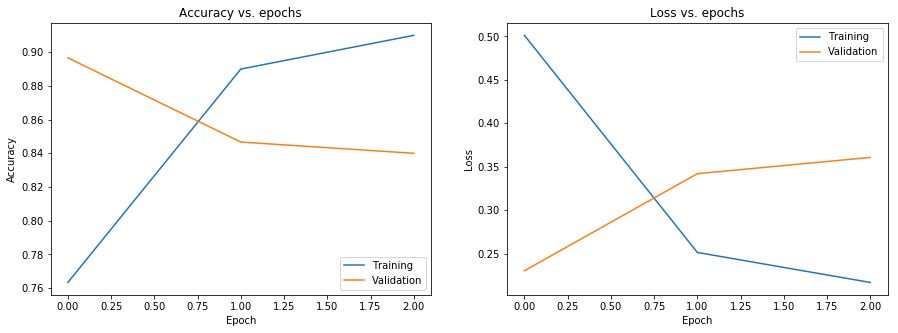

In [20]:
# plot accuracy vs epoch and loss vs epoch

plt.figure(figsize=(15, 5))
plt.subplot(121)
try:
    plt.plot(history_frozen_new_model.history['accuracy'])
    plt.plot(history_frozen_new_model.history['val_accuracy'])
except KeyError:
    plt.plot(history_frozen_new_model.history['acc'])
    plt.plot(history_frozen_new_model.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')

plt.subplot(122)
plt.plot(history_frozen_new_model.history['loss'])
plt.plot(history_frozen_new_model.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

#### Evaluate the new model

In [21]:
# Evaluate the benchmark model on the test set

new_model_test_loss, new_model_test_acc = frozen_new_model.evaluate(images_test, labels_test, verbose=0)
print("Test loss: {}".format(new_model_test_loss))
print("Test accuracy: {}".format(new_model_test_acc))

Test loss: 0.3721174136797587
Test accuracy: 0.8533333539962769


#### Compare both models

Finally, a look at the comparison of training, validation and test metrics between the benchmark and transfer learning model.

In [22]:
# Gather the benchmark and new model metrics

benchmark_train_loss = history_benchmark.history['loss'][-1]
benchmark_valid_loss = history_benchmark.history['val_loss'][-1]

try:
    benchmark_train_acc = history_benchmark.history['acc'][-1]
    benchmark_valid_acc = history_benchmark.history['val_acc'][-1]
except KeyError:
    benchmark_train_acc = history_benchmark.history['accuracy'][-1]
    benchmark_valid_acc = history_benchmark.history['val_accuracy'][-1]

new_model_train_loss = history_frozen_new_model.history['loss'][-1]
new_model_valid_loss = history_frozen_new_model.history['val_loss'][-1]

try:
    new_model_train_acc = history_frozen_new_model.history['acc'][-1]
    new_model_valid_acc = history_frozen_new_model.history['val_acc'][-1]
except KeyError:
    new_model_train_acc = history_frozen_new_model.history['accuracy'][-1]
    new_model_valid_acc = history_frozen_new_model.history['val_accuracy'][-1]

In [23]:
# Compile the metrics into a pandas DataFrame and display the table

comparison_table = pd.DataFrame([
    ['Training loss', benchmark_train_loss, new_model_train_loss],
    ['Training accuracy', benchmark_train_acc, new_model_train_acc],
    ['Validation loss', benchmark_valid_loss, new_model_valid_loss],
    ['Validation accuracy', benchmark_valid_acc, new_model_valid_acc],
    ['Test loss', benchmark_test_loss, new_model_test_loss],
    ['Test accuracy', benchmark_test_acc, new_model_test_acc]],
    columns=['Metric', 'Benchmark CNN', 'Transfer learning CNN'])

comparison_table.index=[''] * 6
comparison_table

,Metric,Benchmark CNN,Transfer learning CNN
,Training loss,0.646308,0.216814
,Training accuracy,0.645000,0.910000
,Validation loss,0.709945,0.360696
,Validation accuracy,0.516667,0.840000
,Test loss,0.700380,0.372117
,Test accuracy,0.520000,0.853333


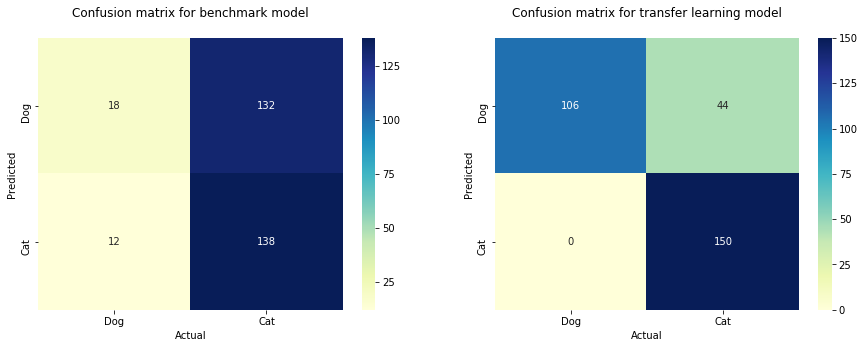

In [24]:
# Plot confusion matrices for benchmark and transfer learning models

plt.figure(figsize=(15, 5))

preds = benchmark_model.predict(images_test)
preds = (preds >= 0.5).astype(np.int32)
cm = confusion_matrix(labels_test, preds)
df_cm = pd.DataFrame(cm, index=['Dog', 'Cat'], columns=['Dog', 'Cat'])
plt.subplot(121)
plt.title("Confusion matrix for benchmark model\n")
sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu")
plt.ylabel("Predicted")
plt.xlabel("Actual")

preds = frozen_new_model.predict(images_test)
preds = (preds >= 0.5).astype(np.int32)
cm = confusion_matrix(labels_test, preds)
df_cm = pd.DataFrame(cm, index=['Dog', 'Cat'], columns=['Dog', 'Cat'])
plt.subplot(122)
plt.title("Confusion matrix for transfer learning model\n")
sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu")
plt.ylabel("Predicted")
plt.xlabel("Actual")
plt.show()

The model created through transfer learning has a significantly better performance than the benchmark model at classifying and predicting the labels, which are 'dog' and 'cat'. This project highlights the benefits of using and modifying a prebuilt model that has been extensively trained on a vast amount of datasets to create an efficient deep learning model trained on a small amount of dataset, which optimally generalizes better to an unseen dataset through a technique called **TRANSFER LEARNING**.